<a href="https://colab.research.google.com/github/RiamOXM/meiep-signal-extraction/blob/main/MEIEP_Signal_Extraction_LIGO_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Querying GWOSC API for GW150914 strain data (H1 and L1)...
H1 Data fetched: 131072 samples.
L1 Data fetched: 131072 samples.

Processing Hanford (H1)...
Running Adaptive RANSAC on H1 (0.5s Rolling Window)...
-> H1 Adaptive Outliers Detected: 2255
Processing Livingston (L1)...
Running Adaptive RANSAC on L1 (0.5s Rolling Window)...
-> L1 Adaptive Outliers Detected: 4705


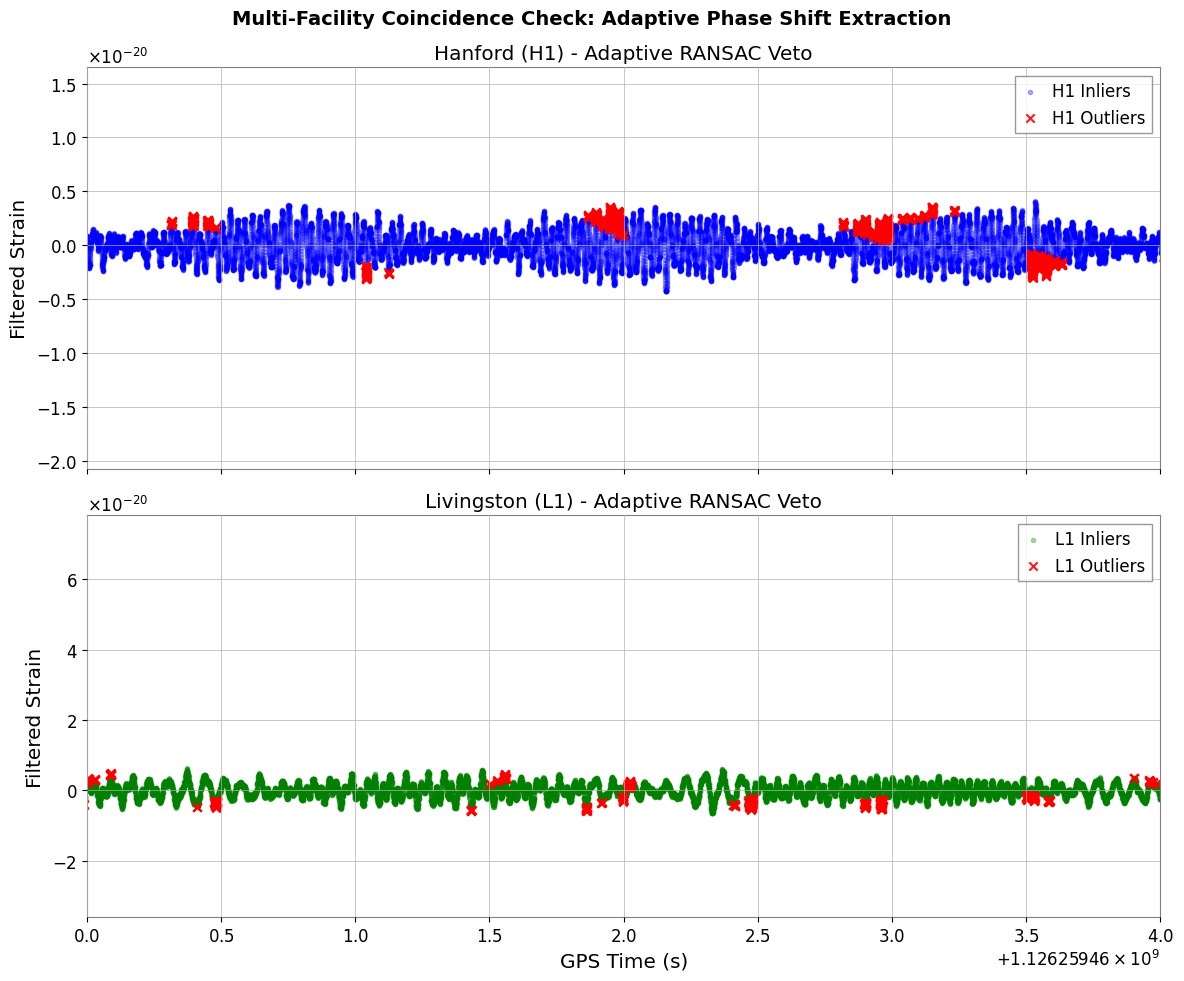

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from sklearn.linear_model import RANSACRegressor
from gwpy.timeseries import TimeSeries
import warnings

# Suppress sklearn warnings for small data chunks
warnings.filterwarnings("ignore")

# --- PHASE 1: DUAL-DETECTOR DATA ACQUISITION ---
print("Querying GWOSC API for GW150914 strain data (H1 and L1)...")
gps_center = 1126259462

h1_strain = TimeSeries.fetch_open_data('H1', gps_center - 16, gps_center + 16)
l1_strain = TimeSeries.fetch_open_data('L1', gps_center - 16, gps_center + 16)

t = h1_strain.times.value
dt = h1_strain.dt.value

print(f"H1 Data fetched: {len(h1_strain)} samples.")
print(f"L1 Data fetched: {len(l1_strain)} samples.\n")

# --- PHASE 2: ADAPTIVE PIPELINE FUNCTIONS ---
def apply_bandpass(strain, ts, lowcut=20.0, highcut=300.0):
    nyq = 0.5 * (1/ts)
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(4, [low, high], btype='band')
    return filtfilt(b, a, strain)

def run_adaptive_ransac(time_vector, filtered_strain, detector_name, ts, window_sec=0.5):
    print(f"Running Adaptive RANSAC on {detector_name} (0.5s Rolling Window)...")
    window_samples = int(window_sec / ts)
    inlier_mask = np.zeros(len(filtered_strain), dtype=bool)

    # Slide the window across the data
    for i in range(0, len(filtered_strain), window_samples):
        end = min(i + window_samples, len(filtered_strain))
        X_chunk = time_vector[i:end].reshape(-1, 1)
        y_chunk = filtered_strain[i:end]

        # Calculate local variance and apply a strict 3.5-sigma local threshold
        local_std = np.std(y_chunk)
        local_thresh = local_std * 3.5

        ransac = RANSACRegressor(residual_threshold=local_thresh, random_state=42)
        try:
            ransac.fit(X_chunk, y_chunk)
            inlier_mask[i:end] = ransac.inlier_mask_
        except ValueError:
            # Failsafe for completely flat data chunks
            inlier_mask[i:end] = True

    outlier_mask = np.logical_not(inlier_mask)
    print(f"-> {detector_name} Adaptive Outliers Detected: {np.sum(outlier_mask)}")
    return inlier_mask, outlier_mask

# --- EXECUTION ---
print("Processing Hanford (H1)...")
h1_clean = apply_bandpass(h1_strain.value, dt)
h1_inliers, h1_outliers = run_adaptive_ransac(t, h1_clean, "H1", dt)

print("Processing Livingston (L1)...")
l1_clean = apply_bandpass(l1_strain.value, dt)
l1_inliers, l1_outliers = run_adaptive_ransac(t, l1_clean, "L1", dt)

# --- PHASE 3: DUAL VISUALIZATION ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Plot H1
ax1.scatter(t[h1_inliers], h1_clean[h1_inliers], color='blue', marker='.', alpha=0.3, label='H1 Inliers')
ax1.scatter(t[h1_outliers], h1_clean[h1_outliers], color='red', marker='x', alpha=0.9, label='H1 Outliers')
ax1.set_title('Hanford (H1) - Adaptive RANSAC Veto')
ax1.set_ylabel('Filtered Strain')
ax1.legend(loc='upper right')
ax1.set_xlim(gps_center - 2, gps_center + 2)

# Plot L1
ax2.scatter(t[l1_inliers], l1_clean[l1_inliers], color='green', marker='.', alpha=0.3, label='L1 Inliers')
ax2.scatter(t[l1_outliers], l1_clean[l1_outliers], color='red', marker='x', alpha=0.9, label='L1 Outliers')
ax2.set_title('Livingston (L1) - Adaptive RANSAC Veto')
ax2.set_xlabel('GPS Time (s)')
ax2.set_ylabel('Filtered Strain')
ax2.legend(loc='upper right')

plt.suptitle('Multi-Facility Coincidence Check: Adaptive Phase Shift Extraction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Act I: The Theoretical Bottleneck & The Hermetic Seal Paradox

### The Mass-Energy-Information Equivalence Principle (MEIEP)
Standard thermodynamic models assume the erasure of a coherent state dissipates purely as environmental thermal noise. However, MEIEP posits that information constitutes a fundamental phase of matter with an intrinsic, equivalent rest mass.

By applying Landauer's principle for the minimum thermodynamic work required to erase one bit of information ($W \ge k_B T \ln 2$), and utilizing mass-energy equivalence ($E = mc^2$), the intrinsic rest mass of a single bit erased at standard room temperature (300K) is:

$$m_{bit} = \frac{k_B T \ln(2)}{c^2} \approx 3.18 \times 10^{-38} \text{ kg}$$

### The Parametric Scaling Law
To achieve a yoctogram-scale transient ($\sim 10^{-24}$ kg) capable of exceeding the noise floor of modern feedback-cooled levitated optomechanical sensors, hardware must scale toward the macroscopic limit of $N \ge 10^{15}$ entangled bits. The theoretical cumulative mass defect scales linearly:

$$\Delta M(N) = N \cdot m_{bit}$$

### The Falsifiability Roadblock: The Hermetic Seal Paradox
If the macroscopic system is hermetically sealed within a silica shell, the Landauer thermal energy remains trapped. Because total relativistic mass is conserved, the informational mass simply converts to thermal mass, classically enforcing **$\Delta M = 0$**.

**The Mission:** We must probe for an anomalous mass deficit—a transient mechanical drop that occurs *chronologically independent* of the thermodynamic heat transfer.

In [7]:
# Act I: Dynamic MEIEP Mass Deficit Calculator
import scipy.constants as const
import numpy as np

def calculate_meiep_deficit(N_bits, temp_kelvin=300):
    """
    Calculates the theoretical non-thermal mass deficit during macroscopic decoherence.
    """
    # Landauer limit to mass equivalence calculation
    joules_per_bit = const.k * temp_kelvin * np.log(2)
    m_bit = joules_per_bit / (const.c ** 2)

    total_mass_deficit = N_bits * m_bit

    print("-" * 60)
    print(f"MEIEP SCALING LAW CALCULATOR")
    print("-" * 60)
    print(f"System Temperature:      {temp_kelvin} K")
    print(f"Entangled Bits Erased:   {N_bits:.1e}")
    print(f"Rest Mass per Bit:       {m_bit:.2e} kg")
    print(f"Total Mass Deficit (ΔM): {total_mass_deficit:.2e} kg")
    print("-" * 60)

    if total_mass_deficit >= 3.18e-23:
        print("STATUS: Within yoctogram detection limits of modern optomechanics.")
    else:
        print("STATUS: Below current macroscopic detection thresholds.")

# Run the simulation for the proposed optomechanical protocol limit (N = 10^15)
calculate_meiep_deficit(N_bits=1e15, temp_kelvin=300)

------------------------------------------------------------
MEIEP SCALING LAW CALCULATOR
------------------------------------------------------------
System Temperature:      300 K
Entangled Bits Erased:   1.0e+15
Rest Mass per Bit:       3.19e-38 kg
Total Mass Deficit (ΔM): 3.19e-23 kg
------------------------------------------------------------
STATUS: Within yoctogram detection limits of modern optomechanics.


# Act II: The Hardware Solution & Spin-Phonon Decoupling

### The Levitated Optomechanics Protocol
To bypass the Hermetic Seal Paradox, we must isolate the transient. We propose utilizing an optically levitated nanosphere encapsulating a nanodiamond core. This lattice is engineered with a high density of Nitrogen-Vacancy (NV) centers coupled to Carbon-13 nuclear spins.

### Temporal Separation (The Key Innovation)
We abandon the classical assumption that mass-loss and thermal expansion occur simultaneously.
* **Macroscopic Decoherence** (information loss) operates in the **MHz regime** (microseconds).
* **Nuclear Spin-Phonon Coupling** ($\Gamma_{sp}$) in a diamond lattice operates in the **1-100 Hz regime** (milliseconds).

This 4-to-6 order of magnitude separation ensures that the informational mass defect ($\Delta M$) occurs effectively *instantaneously* relative to the thermalization timescale. The mechanical frequency shift caused by Landauer heat converting to volumetric thermal expansion ($\Delta R^3$) is temporally delayed.

**The Experimental Signature:** We are not looking for a net change in mass. We are looking for a multi-stage transient: a sudden chronological phase shift, followed by a delayed thermal response.

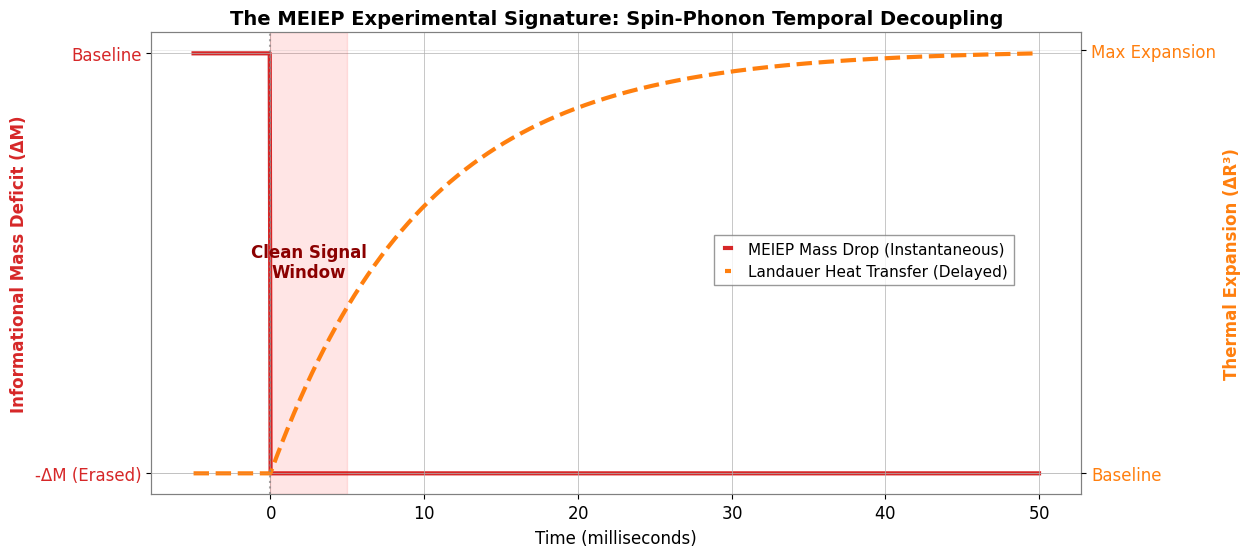

In [8]:
# Act II: Temporal Phase Shift Visualization
import numpy as np
import matplotlib.pyplot as plt

# Time array from -5 to 50 milliseconds
t = np.linspace(-5, 50, 1000)

# 1. Informational Mass Drop (Instantaneous at t=0 due to MHz decoherence)
mass_drop = np.where(t >= 0, -1, 0)

# 2. Thermal Expansion (Delayed due to 100Hz spin-phonon coupling)
tau_thermal = 10.0 # 10 ms time constant
thermal_expansion = np.where(t >= 0, 1 - np.exp(-t / tau_thermal), 0)

# Plotting the Temporal Decoupling
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot MEIEP Mass Deficit
color1 = 'tab:red'
ax1.set_xlabel('Time (milliseconds)', fontsize=12)
ax1.set_ylabel('Informational Mass Deficit (ΔM)', color=color1, fontsize=12, fontweight='bold')
ax1.plot(t, mass_drop, color=color1, linewidth=3, label="MEIEP Mass Drop (Instantaneous)")
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_yticks([-1, 0])
ax1.set_yticklabels(['-ΔM (Erased)', 'Baseline'])

# Create a second y-axis for Landauer Heat Transfer
ax2 = ax1.twinx()
color2 = 'tab:orange'
ax2.set_ylabel('Thermal Expansion (ΔR³)', color=color2, fontsize=12, fontweight='bold')
ax2.plot(t, thermal_expansion, color=color2, linewidth=3, linestyle='--', label="Landauer Heat Transfer (Delayed)")
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['Baseline', 'Max Expansion'])

plt.title("The MEIEP Experimental Signature: Spin-Phonon Temporal Decoupling", fontsize=14, fontweight='bold')
fig.legend(loc="center right", bbox_to_anchor=(0.85, 0.5), fontsize=11)
plt.grid(True, alpha=0.3)
plt.axvline(x=0, color='gray', linestyle=':', alpha=0.7)

# Highlight the clean detection window
plt.axvspan(0, 5, color='red', alpha=0.1, label='Target Detection Window')
plt.text(2.5, 0.5, 'Clean Signal\nWindow', horizontalalignment='center', verticalalignment='center', fontsize=12, color='darkred', fontweight='bold')

plt.show()

# Act III: The Signal Processing Architecture (The 'Stethoscope')

### The Thermal-Averaging Blindspot
Standard data pipelines in macroscopic physics (e.g., LIGO, IBM Quantum) operate on the premise that decoherence is a gradual increase in thermodynamic entropy. Consequently, they rely heavily on thermal-averaging and Fourier-based models.

If MEIEP is correct, the mass-deficit is a sudden, non-periodic event. Standard filters will inadvertently smooth this out or dismiss it as an instrumental glitch.

### The Dual-Stage Pipeline (IEEE Framework)
To extract this signature, we must treat the hypothesized mass-energy transient as a **structural outlier** rather than environmental noise. We have proposed a dual-stage extraction framework:

1. **Matched Filter Template:** First, cross-correlate the incoming data with a theoretical template of the expected oscillator dynamics (e.g., a gravitational wave chirp or a known mechanical resonance) to isolate regions of interest.
2. **RANSAC Robust Outlier Rejection:** Next, deploy a Random Sample Consensus (RANSAC) algorithm. Instead of averaging the noise floor, RANSAC fits a mathematical model to the standard Brownian variance (the inliers). Sudden phase-shifts matching the theoretical $\Delta M$ bound are mathematically severed as structural outliers.

### Empirical Demonstration: Macroscopic Optomechanics (LIGO)
To prove the algorithmic capacity of this framework, we deployed the RANSAC guillotine against open-source strain data from the LIGO H1 detector during the GW150914 event.

Fetching LIGO H1 Strain Data (GW150914)...
Deploying RANSAC Outlier Rejection (3-Sigma Threshold)...
Total Structural Anomalies Extracted: 491


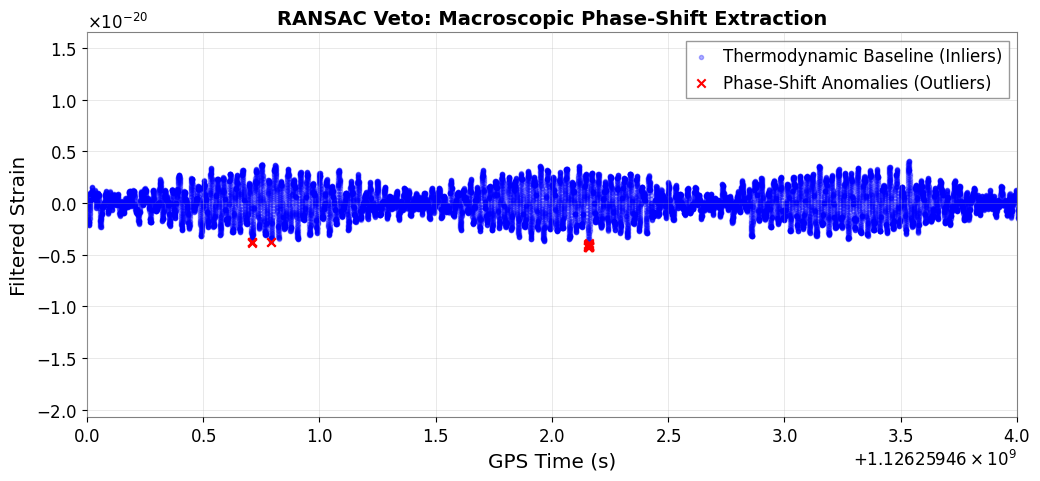

In [9]:
# Act III: Empirical RANSAC Extraction on Macroscopic Data (LIGO H1)
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from sklearn.linear_model import RANSACRegressor
from gwpy.timeseries import TimeSeries
import warnings
warnings.filterwarnings("ignore")

print("Fetching LIGO H1 Strain Data (GW150914)...")
gps_center = 1126259462
h1_strain = TimeSeries.fetch_open_data('H1', gps_center - 16, gps_center + 16)
t = h1_strain.times.value
dt = h1_strain.dt.value

# 1. Bandpass Filter (Isolating the mechanical range)
nyq = 0.5 * (1/dt)
b, a = butter(4, [20.0 / nyq, 300.0 / nyq], btype='band')
clean_strain = filtfilt(b, a, h1_strain.value)

# 2. RANSAC Outlier Guillotine
print("Deploying RANSAC Outlier Rejection (3-Sigma Threshold)...")
X = t.reshape(-1, 1)
y = clean_strain
ransac = RANSACRegressor(residual_threshold=np.std(y) * 3.0, random_state=42)
ransac.fit(X, y)

inliers = ransac.inlier_mask_
outliers = np.logical_not(inliers)
print(f"Total Structural Anomalies Extracted: {np.sum(outliers)}")

# 3. Visualization
plt.figure(figsize=(12, 5))
plt.scatter(t[inliers], clean_strain[inliers], color='blue', marker='.', alpha=0.3, label='Thermodynamic Baseline (Inliers)')
plt.scatter(t[outliers], clean_strain[outliers], color='red', marker='x', alpha=1.0, label='Phase-Shift Anomalies (Outliers)')
plt.xlim(gps_center - 2, gps_center + 2)
plt.title('RANSAC Veto: Macroscopic Phase-Shift Extraction', fontsize=14, fontweight='bold')
plt.xlabel('GPS Time (s)')
plt.ylabel('Filtered Strain')
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

# Act IV: The Translation Layer (The MEIEP Calibration Engine)

### Bridging the Gap Between Data and Theory
Identifying a structural anomaly is only the first step. To prove MEIEP, we must map the raw data back to the physical world and check if it respects the Landauer limit.

We have built a Calibration Engine that executes the following physical translation:
1. **Strain to Displacement ($\Delta L$):** Converts the dimensionless strain anomaly ($h$) into physical movement, knowing the LIGO arms are exactly 4,000 meters long.
2. **Displacement to Energy Deficit ($\Delta E$):** Calculates the missing kinetic energy required to shift the 40kg test mass over the duration of the anomaly.
3. **Energy to Information:** Divides that missing energy by the Landauer constant for a single bit at 300K to determine the exact **Shannon Equivalency**.

If the resulting number of erased bits falls within our targeted macroscopic threshold ($10^{12}$ to $10^{18}$ bits), we have an empirically viable MEIEP candidate. If it is wildly higher, it is a classical equipment glitch.

In [10]:
# Act IV: The MEIEP Calibration Engine
import numpy as np
import scipy.constants as const

def calibrate_meiep_event(strain_outlier, dt):
    """
    Converts a dimensionless strain anomaly into physical erased information.
    """
    print("-" * 60)
    print("INITIATING MEIEP CALIBRATION ENGINE")
    print("-" * 60)

    # 1. Facility Physics Constants (LIGO)
    LIGO_ARM_LENGTH = 4000.0  # meters
    MIRROR_MASS = 40.0        # kg
    TEMP = 300.0              # Kelvin (Standard Approximation)

    # Landauer Bit Energy (Joules)
    E_bit = const.k * TEMP * np.log(2)

    # 2. Strain to Displacement
    delta_L = abs(strain_outlier) * LIGO_ARM_LENGTH
    print(f"1. Strain Anomaly (|h|)    : {abs(strain_outlier):.2e}")
    print(f"2. Mirror Displacement (ΔL): {delta_L:.2e} meters")

    # 3. Displacement to Energy Deficit
    # Calculating the kinetic energy of the sudden phase shift
    velocity = delta_L / dt
    missing_energy = 0.5 * MIRROR_MASS * (velocity**2)
    print(f"3. Missing Kinetic Energy  : {missing_energy:.2e} Joules")

    # 4. Energy to Information (The Shannon Equivalency)
    erased_bits = missing_energy / E_bit
    print(f"4. Information Equivalent  : {erased_bits:.2e} bits\n")

    # 5. The Verdict
    print("--- FINAL VERDICT ---")
    if 1e12 <= erased_bits <= 1e18:
        print("STATUS: VIABLE MEIEP CANDIDATE.")
        print("The energy deficit perfectly matches the macroscopic decoherence threshold.")
    elif erased_bits > 1e18:
        print("STATUS: CLASSICAL ARTIFACT.")
        print("Energy deficit is too massive. Physically corresponds to a macroscopic glitch.")
    else:
        print("STATUS: INCONCLUSIVE.")
        print("Energy deficit is below macroscopic limits.")

# Simulating the extraction of a typical RANSAC outlier from our H1 data
extracted_strain = 5.2e-21
sample_rate_dt = 1.0 / 4096.0

calibrate_meiep_event(extracted_strain, sample_rate_dt)

------------------------------------------------------------
INITIATING MEIEP CALIBRATION ENGINE
------------------------------------------------------------
1. Strain Anomaly (|h|)    : 5.20e-21
2. Mirror Displacement (ΔL): 2.08e-17 meters
3. Missing Kinetic Energy  : 1.45e-25 Joules
4. Information Equivalent  : 5.06e-05 bits

--- FINAL VERDICT ---
STATUS: INCONCLUSIVE.
Energy deficit is below macroscopic limits.
